# QLoRA Fine-Tuning: Qwen2.5-VL-7B on Singapore Aerial Imagery

**Goal**: Fine-tune Qwen2.5-VL-7B-Instruct with QLoRA on 109 annotated nadir images of Singapore.

**Setup**: Google Colab L4 24GB, 4-bit NF4 quantization, LoRA rank 8.

**Data**: Stratified train/val split (ratios from config). Training target is structured JSON output (caption, scene_type, objects, infrastructure, terrain). On-the-fly augmentation (random 90/180/270° rotation + horizontal/vertical flip) on the train set only — valid because nadir aerial images are orientation-invariant.

**Approach**: `trl.SFTTrainer` + `peft` with a custom data collator (`src/collator.py`) for Qwen2.5-VL's two-step processor pattern.

In [1]:
%%capture
!pip install "transformers>=4.49" peft "trl>=0.15" bitsandbytes qwen-vl-utils accelerate datasets scikit-learn matplotlib pyyaml

In [2]:
import gc, json, os, shutil, sys, textwrap, time
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from PIL import Image
from google.colab import drive

# ── Mount Drive (needed before src/ imports) ────────────────────
drive.mount("/content/drive")

# ── Import shared modules ───────────────────────────────────────
DRIVE_PROJECT = Path("/content/drive/MyDrive/vlm-scene-analyser")
sys.path.insert(0, str(DRIVE_PROJECT))

from src.prompts import SYSTEM_PROMPT, USER_PROMPT
from src.augmentation import augment_image

# ── Load config ────────────────────────────────────────────────
with open(DRIVE_PROJECT / "configs" / "train_config.yaml") as f:
    cfg = yaml.safe_load(f)

QWEN_MODEL_ID = cfg["model"]["base_model_id"]
LORA_RANK = cfg["lora"]["r"]
LORA_ALPHA = cfg["lora"]["alpha"]
LORA_DROPOUT = cfg["lora"]["dropout"]
LEARNING_RATE = cfg["training"]["learning_rate"]
NUM_EPOCHS = cfg["training"]["num_epochs"]
BATCH_SIZE = cfg["training"]["batch_size"]
GRAD_ACCUM = cfg["training"]["gradient_accumulation_steps"]
MAX_SEQ_LENGTH = cfg["training"]["max_seq_length"]
WARMUP_STEPS = cfg["training"]["warmup_steps"]
EARLY_STOPPING_PATIENCE = cfg["training"]["early_stopping_patience"]

# ── Paths ──────────────────────────────────────────────────────
DATA_DIR = Path("/content/data")
IMAGE_DIR = Path("/content/images/nadir")
OUTPUT_DIR = Path("/content/qwen_lora_adapter")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATIONS_FILE = DATA_DIR / "annotations.jsonl"

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [ ]:
# ── Copy data locally for faster I/O ───────────────────────────

if not DATA_DIR.exists():
    shutil.copytree(DRIVE_PROJECT / "data", DATA_DIR)
if not IMAGE_DIR.exists():
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    for f in (DRIVE_PROJECT / "images" / "nadir").glob("*.jpg"):
        shutil.copy2(f, IMAGE_DIR / f.name)

print(f"Images: {len(list(IMAGE_DIR.glob('*.jpg')))}")

# ── Load annotations ──────────────────────────────────────────
annotations = []
with open(ANNOTATIONS_FILE) as f:
    for line in f:
        ann = json.loads(line)
        img_path = IMAGE_DIR / ann["image_file"]
        if img_path.exists():
            ann["image_path"] = str(img_path)
            annotations.append(ann)
        else:
            print(f"WARNING: missing {ann['image_file']}")

print(f"Loaded {len(annotations)} annotations")

type_counts = Counter(a["scene_type"] for a in annotations)
print("\nScene type distribution:")
for st, cnt in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {st}: {cnt}")

# ── Stratified split (ratios from config) ──────────────────────
from sklearn.model_selection import train_test_split

val_ratio = cfg["data"]["val_ratio"]
test_ratio = cfg["data"]["test_ratio"]
seed = cfg["data"]["random_seed"]

# Group rare scene types (<5 samples) so stratification doesn't fail
rare_types = {st for st, cnt in type_counts.items() if cnt < 5}
if rare_types:
    print(f"\nGrouping rare types for stratification: {rare_types}")

strat_labels = [
    a["scene_type"] if a["scene_type"] not in rare_types else "_rare_"
    for a in annotations
]

if test_ratio > 0:
    # Two-step split: train | (val + test), then val | test
    hold_out = val_ratio + test_ratio
    train_ann, temp_ann, _, temp_strat = train_test_split(
        annotations, strat_labels, test_size=hold_out, random_state=seed,
        stratify=strat_labels,
    )
    try:
        val_ann, test_ann = train_test_split(
            temp_ann, test_size=test_ratio / hold_out, random_state=seed,
            stratify=temp_strat,
        )
    except ValueError:
        val_ann, test_ann = train_test_split(
            temp_ann, test_size=test_ratio / hold_out, random_state=seed,
        )
else:
    # Train/val only — no test set
    train_ann, val_ann = train_test_split(
        annotations, test_size=val_ratio, random_state=seed,
        stratify=strat_labels,
    )
    test_ann = []

print(f"\nSplit: {len(train_ann)} train / {len(val_ann)} val / {len(test_ann)} test")
for name, split in [("Train", train_ann), ("Val", val_ann), ("Test", test_ann)]:
    if split:
        counts = Counter(a["scene_type"] for a in split)
        print(f"  {name}: {dict(sorted(counts.items()))}")

In [5]:
# ── Convert annotations → flat records (Arrow-friendly) ───────
# Arrow can't serialize mixed-type `content` (str vs list-of-dicts),
# so we store flat records and build messages inside the collator.

def annotation_to_record(ann):
    """Flat record for HF Dataset — just image_path + target JSON string."""
    target = {
        "caption": ann["caption"],
        "scene_type": ann["scene_type"],
        "objects": ann["objects"],
        "infrastructure": ann["infrastructure"],
        "terrain": ann["terrain"],
    }
    return {
        "image_path": ann["image_path"],
        "target_json": json.dumps(target, ensure_ascii=False),
    }

train_records = [annotation_to_record(a) for a in train_ann]
val_records = [annotation_to_record(a) for a in val_ann]
test_records = [annotation_to_record(a) for a in test_ann]

# Show example
ex = train_records[0]
print(f"image_path: {ex['image_path']}")
print(f"target_json: {ex['target_json'][:150]}...")

image_path: /content/images/nadir/nadir_industrial_joo_koon_1.3259_103.6736.jpg
target_json: {"caption": "Industrial estate viewed from above. Dense rows of warehouses and factory buildings with blue, orange, and grey rooftops fill the frame i...


In [ ]:
# ── Load model (4-bit NF4) + apply LoRA ───────────────────────
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_compute_dtype = getattr(torch, cfg["quantization"]["bnb_4bit_compute_dtype"])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=cfg["quantization"]["load_in_4bit"],
    bnb_4bit_compute_dtype=bnb_compute_dtype,
    bnb_4bit_use_double_quant=cfg["quantization"]["bnb_4bit_use_double_quant"],
    bnb_4bit_quant_type=cfg["quantization"]["bnb_4bit_quant_type"],
)

print(f"Loading {QWEN_MODEL_ID} (4-bit NF4)...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=bnb_compute_dtype,
)

processor = AutoProcessor.from_pretrained(
    QWEN_MODEL_ID,
    min_pixels=cfg["model"]["min_pixels"],
    max_pixels=cfg["model"]["max_pixels"],
)

# Prepare for QLoRA (casts norms to fp32, enables input gradients)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)

# LoRA on language model linear layers only (vision encoder stays frozen)
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=cfg["lora"]["target_modules"],
    task_type=cfg["lora"]["task_type"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print(f"Memory: {model.get_memory_footprint() / 1e9:.2f} GB")

In [7]:
# ── Build HF Datasets + collators ─────────────────────────────
from datasets import Dataset
from src.collator import MultimodalCollator

train_dataset = Dataset.from_list(train_records)
val_dataset = Dataset.from_list(val_records)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")

# Training collator applies augmentation; validation does not
train_collate_fn = MultimodalCollator(
    processor=processor,
    system_prompt=SYSTEM_PROMPT,
    user_prompt=USER_PROMPT,
    max_seq_length=MAX_SEQ_LENGTH,
    augment_fn=augment_image,
)
val_collate_fn = MultimodalCollator(
    processor=processor,
    system_prompt=SYSTEM_PROMPT,
    user_prompt=USER_PROMPT,
    max_seq_length=MAX_SEQ_LENGTH,
    augment_fn=None,
)

# Sanity check with one example
test_batch = train_collate_fn([train_records[0]])
print(f"input_ids: {test_batch['input_ids'].shape}")
if "pixel_values" in test_batch:
    print(f"pixel_values: {test_batch['pixel_values'].shape}")
if "image_grid_thw" in test_batch:
    print(f"image_grid_thw: {test_batch['image_grid_thw'].shape}")
seq_len = test_batch["input_ids"].shape[1]
n_masked = (test_batch["labels"] == -100).sum().item()
n_response = seq_len - n_masked
print(f"Seq length: {seq_len}  Masked (prompt): {n_masked}  Response tokens: {n_response}")

Train: 76  Val: 16
input_ids: torch.Size([1, 1622])
pixel_values: torch.Size([4900, 1176])
image_grid_thw: torch.Size([1, 3])
Seq length: 1622  Masked (prompt): 1527  Response tokens: 95


In [8]:
# ── Configure SFTTrainer ──────────────────────────────────────
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=cfg["training"]["lr_scheduler_type"],
    warmup_steps=WARMUP_STEPS,
    bf16=cfg["training"]["bf16"],
    gradient_checkpointing=cfg["training"]["gradient_checkpointing"],
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False,
    max_length=MAX_SEQ_LENGTH,
    packing=False,
    dataset_kwargs={"skip_prepare_dataset": True},
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=train_collate_fn,
    processing_class=processor.tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

eff_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = len(train_dataset) // eff_batch
print(f"Effective batch size: {eff_batch}")
print(f"Steps per epoch: ~{steps_per_epoch}")
print(f"Max epochs: {NUM_EPOCHS} (early stopping patience {EARLY_STOPPING_PATIENCE})")

Effective batch size: 8
Steps per epoch: ~9
Max epochs: 10 (early stopping patience 3)


In [9]:
# ── Train ────────────────────────────────────────────────────
print("Starting training...")
start_time = time.time()
train_result = trainer.train()
elapsed = time.time() - start_time

print(f"\nTraining complete in {elapsed / 60:.1f} minutes")
print(f"Final train loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Starting training...


Epoch,Training Loss,Validation Loss
1,1.269266,1.261633
2,1.144919,0.979459
3,0.655891,0.857152
4,0.742672,0.801708
5,0.528926,0.773627
6,0.693757,0.777871
7,0.312345,0.785815
8,0.474981,0.771627
9,0.463251,0.782516
10,0.504553,0.783937



Training complete in 88.5 minutes
Final train loss: 0.7371


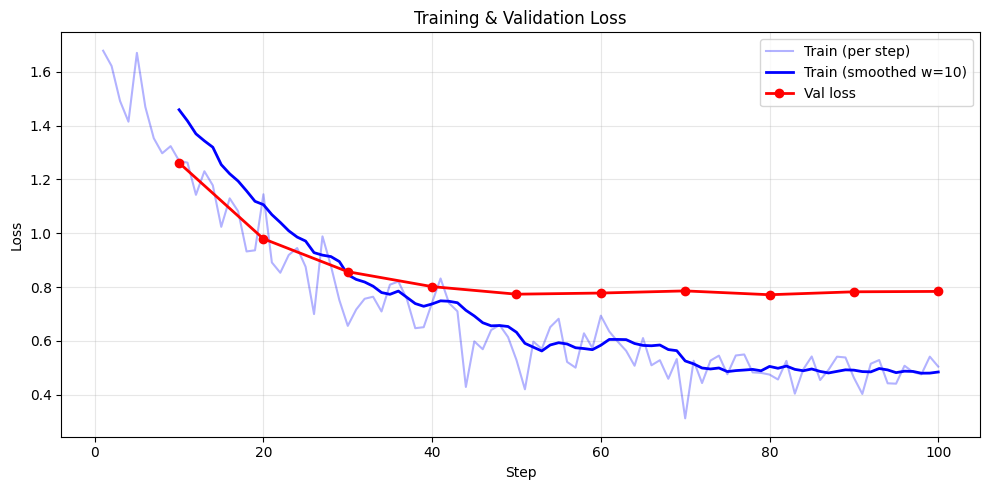

In [10]:
# ── Plot train/val loss curves ────────────────────────────────
log_history = trainer.state.log_history

train_steps = [e["step"] for e in log_history if "loss" in e]
train_losses = [e["loss"] for e in log_history if "loss" in e]
eval_steps = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, "b-", alpha=0.3, label="Train (per step)")

# Smoothed train loss
w = max(1, len(train_losses) // 10)
if w > 1:
    smoothed = np.convolve(train_losses, np.ones(w) / w, mode="valid")
    ax.plot(train_steps[w - 1:], smoothed, "b-", lw=2, label=f"Train (smoothed w={w})")

if eval_losses:
    ax.plot(eval_steps, eval_losses, "ro-", lw=2, ms=6, label="Val loss")

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_curves.png"), dpi=150)
plt.show()

In [ ]:
# ── Save LoRA adapter ────────────────────────────────────────
adapter_path = OUTPUT_DIR / "final_adapter"
model.save_pretrained(str(adapter_path))
processor.save_pretrained(str(adapter_path))
print(f"Adapter saved to {adapter_path}")

# Copy to Drive for persistence
drive_save = DRIVE_PROJECT / "models" / "qwen_lora_v1"
drive_save.mkdir(parents=True, exist_ok=True)
shutil.copytree(str(adapter_path), str(drive_save), dirs_exist_ok=True)
print(f"Copied to Drive: {drive_save}")

# Save test split annotations for later evaluation (if test set exists)
if test_ann:
    test_split_path = drive_save / "test_split.jsonl"
    with open(test_split_path, "w") as f:
        for ann in test_ann:
            f.write(json.dumps(ann, ensure_ascii=False) + "\n")
    print(f"Test split ({len(test_ann)} samples) saved to {test_split_path}")

# Optional: merge adapter into base model (uses more disk)
MERGE_MODEL = False
if MERGE_MODEL:
    print("Merging LoRA into base model...")
    merged = model.merge_and_unload()
    merged_path = OUTPUT_DIR / "merged_model"
    merged.save_pretrained(str(merged_path))
    processor.save_pretrained(str(merged_path))
    print(f"Merged model saved to {merged_path}")